In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

import Ceros as c

# link video:

https://www.youtube.com/watch?v=Kwvi4SP_MOE


# Ejercicio 1

El volumen $V$ de un líquido contenido en un tanque horizontal cilíndrico de radio $r$ y longitud $L$ está relacionado con la profundidad del líquido $h$ por:$$V = \left[ r^2 \cos^{-1} \left( \frac{r - h}{h} \right) - (r - h) \sqrt{2rh - h^2} \right] L$$Nota: En la imagen original parece haber una errata en el denominador del arco coseno ($h$ en lugar de $r$). Se recomienda usar $r$ para que la fórmula sea dimensionalmente consistente.Para $r = 2$, $L = 8$ y $V = 12.5\text{m}^3$. El término del arco coseno calcularlo como:$$\cos^{-1}x = \frac{\pi}{2} - \tan^{-1} \left( \frac{x}{\sqrt{1 - x^2}} \right)$$Realizar el bosquejo de la gráfica de la función de ceros.Determinar $h$, usando un método abierto.Determinar $h$, usando un método cerrado.Dé una justificación de su respuesta.

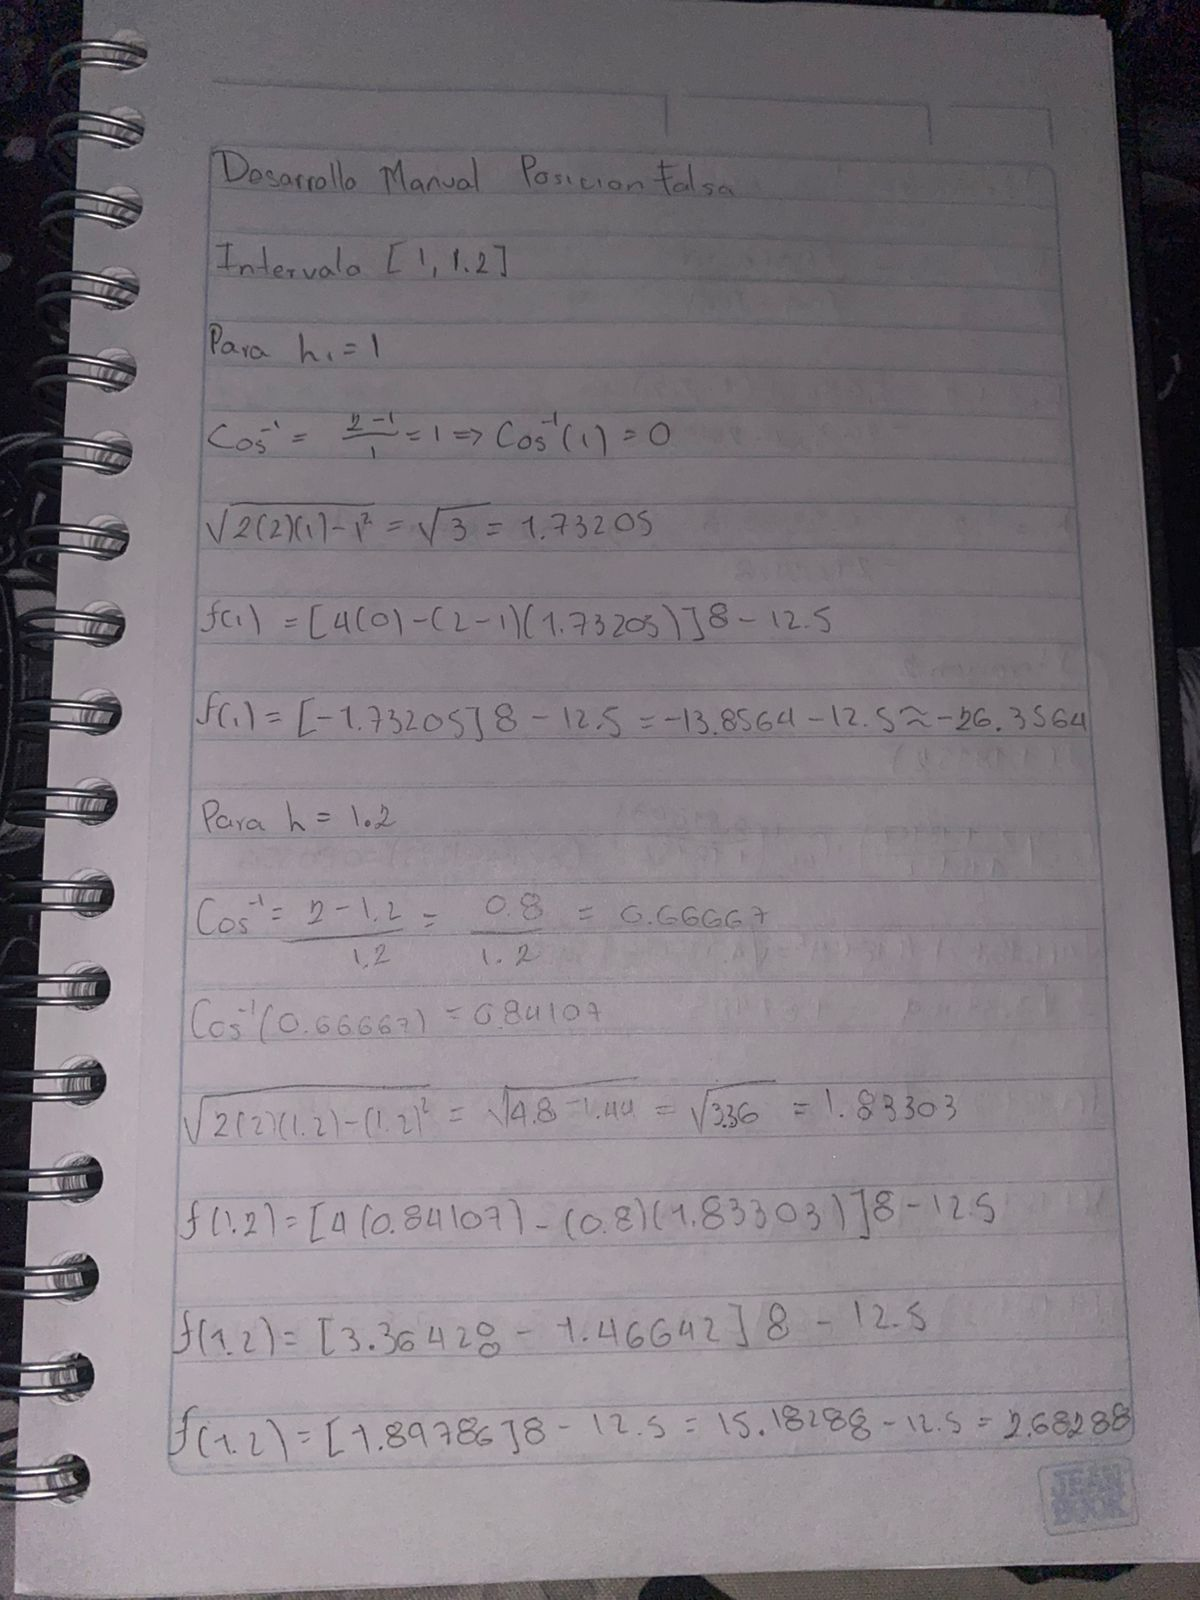

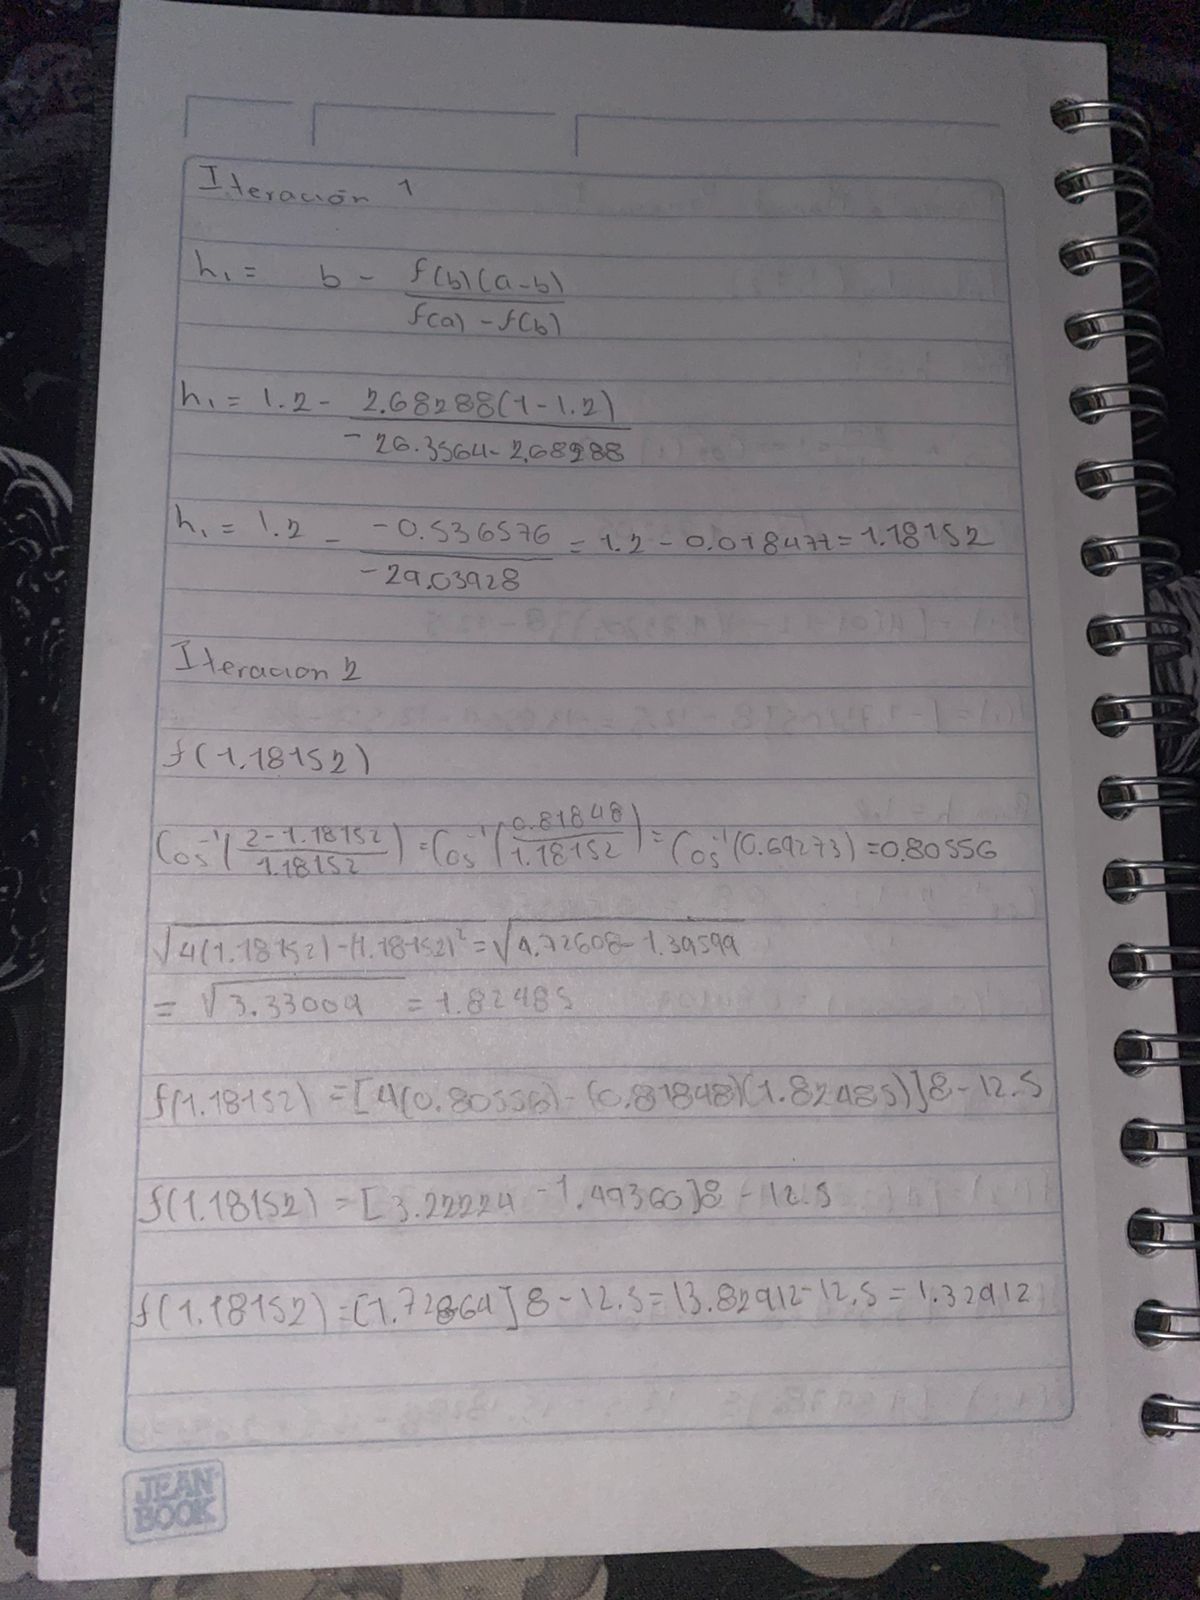

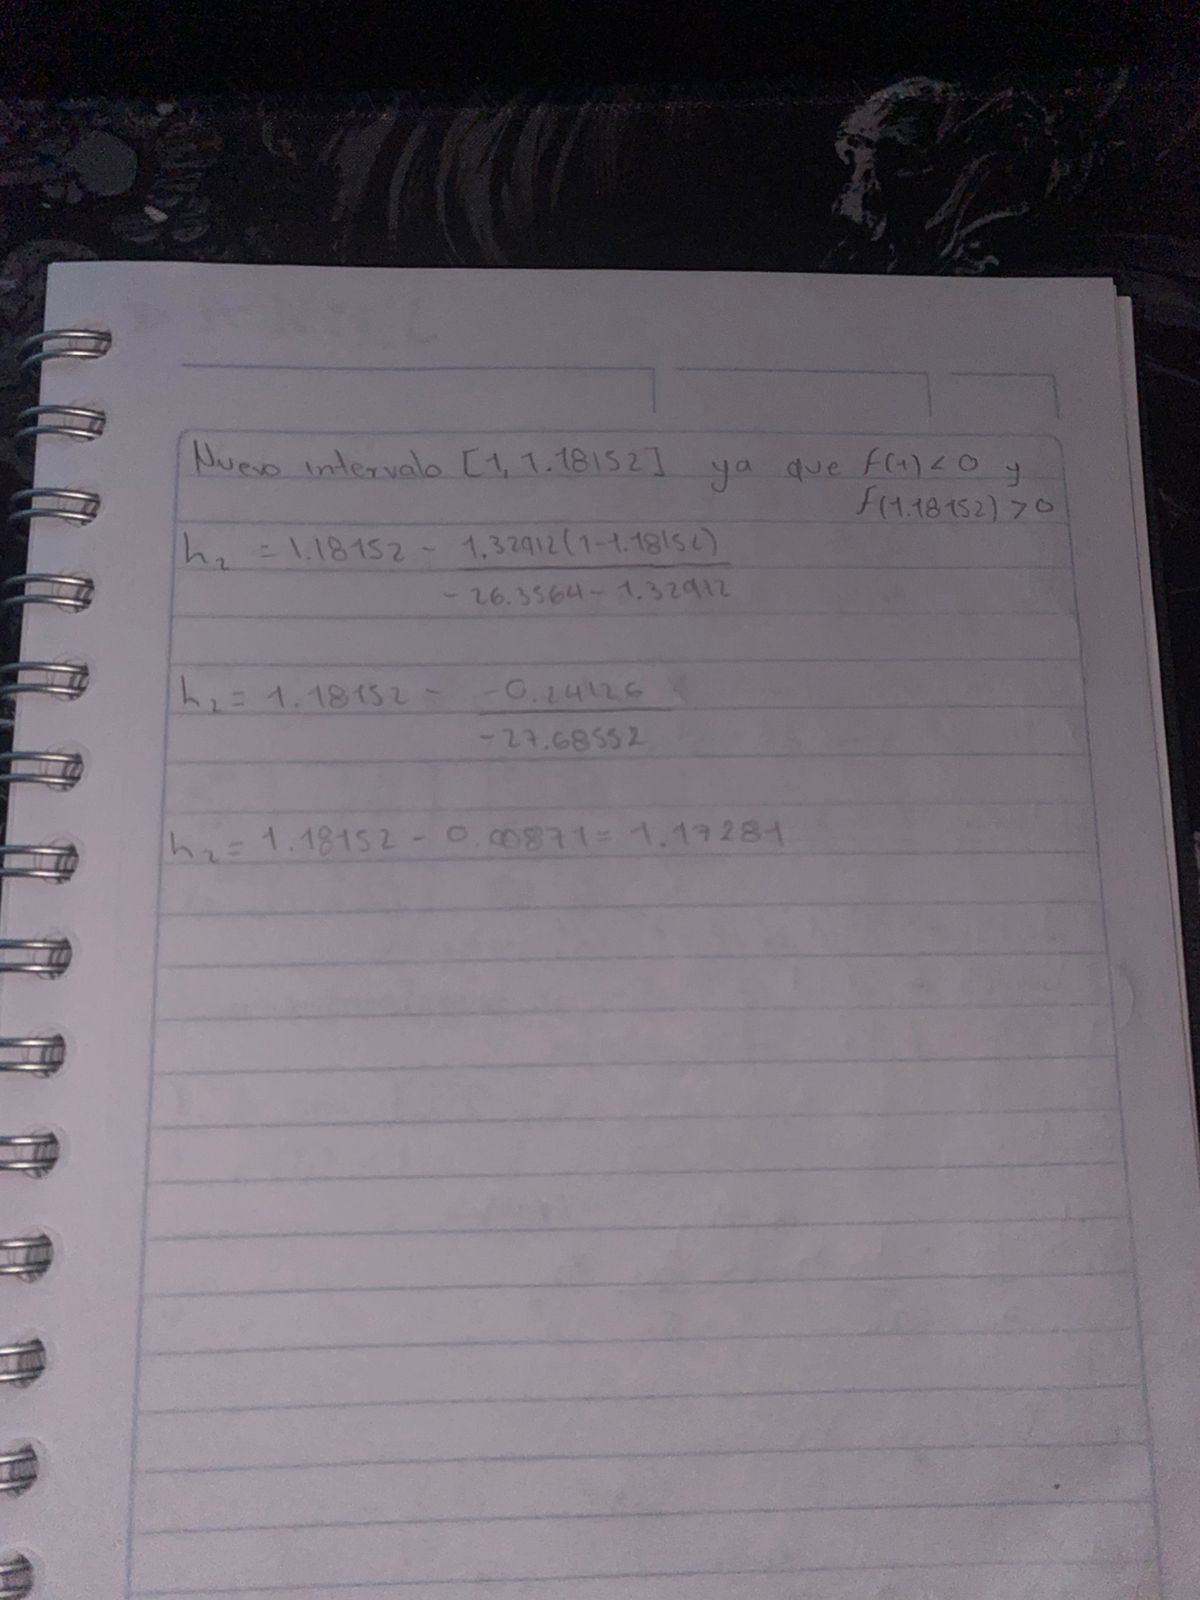

Posicion Falsa
La solucion de al funcion: 1.1643189246038665
La cantidad de iteraciones necesarias fueron 22
solucion abierta: 1.1643189146285142
solucion cerrada: 1.1643189246038665


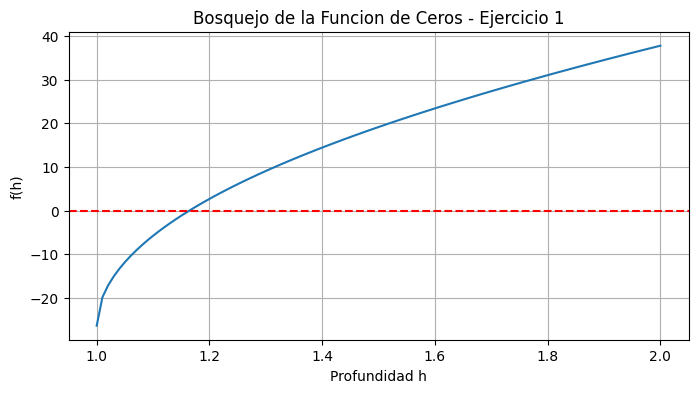

In [3]:
# Necesitamos encontnrar la profundidad h para un tanque con radio r = 2 y longitud L = 8 y con V = 12.5


# Parametros
r = 2
L = 8
V = 12.5
h = sp.symbols('x')


# Funcion
f = (r**2 * sp.acos((r - h) / h) - (r - h) * sp.sqrt(2 * r * h - h ** 2)) * L - V
f_lambda = sp.lambdify(h, f, 'numpy')

# Metodo abierto
sol_abierta, it_n = c.Newton(f, 1.3, 1e-6)
# Metodo cerrado
sol_cerrada = c.PosicionFalsa(f_lambda, 1.0, 1.2, 1e-6)

print(f"solucion abierta: {sol_abierta}")
print(f"solucion cerrada: {sol_cerrada}")


# Bosquejo de la grafica
h_range = np.linspace(1, 2, 100)
plt.figure(figsize=(8, 4))
plt.plot(h_range, f_lambda(h_range))
plt.axhline(0, color='red', linestyle='--')
plt.title("Bosquejo de la Funcion de Ceros - Ejercicio 1")
plt.xlabel("Profundidad h")
plt.ylabel("f(h)")
plt.grid(True)
plt.show()

# Justificacion: El valor h = 1.16 m es correcto ya que al ser un volumen de 12.5 m^3
# frente a una capacidad total de 100.5 m^3 la altura debe ser menor al radio del tanque.

# Ejercicio 2

La ecuación de Ergun, que se da abajo, sirve para describir el flujo de un líquido a través de un lecho empacado. $\Delta P$ es la caída de presión, $\rho$ es la densidad del fluido, $G_o$ es la velocidad másica (el cociente del flujo de masa dividido entre el área de la sección transversal), $D_p$ es el diámetro de las partículas dentro del lecho, $\mu$ es la viscosidad del fluido, $L$ es la longitud del lecho y $\varepsilon$ es la fracción vacía del lecho.$$\frac{\Delta P \rho}{G_o^2} \frac{D_p}{L} \frac{\varepsilon^3}{(1 - \varepsilon)} = 150 \frac{(1 - \varepsilon)}{\left( \frac{D_p G_o}{\mu} \right)} + 1.75$$Realizar el bosquejo de la gráfica de la función de ceros.Dados los siguientes valores para los parámetros encuentre la fracción vacía $\varepsilon$ del lecho, use el método de Bisección.$$\frac{D_p G_o}{\mu} = 1000; \quad \frac{\Delta P \rho}{G_o^2} \frac{D_p}{L} = 10$$Dados los siguientes valores para los parámetros encuentre la fracción vacía $\varepsilon$ del lecho, use el método de la Secante.$$\frac{D_p G_o}{\mu} = 1000; \quad \frac{\Delta P \rho}{G_o^2} \frac{D_p}{L} = 10$$Dé una justificación de su respuesta.

Biseccion
La solucion de al funcion: 0.4618568420410156
La cantidad de iteraciones necesarias fueron 19
Epsilon (Biseccion): 0.4618568420410156
Epsilon (Secante): 0.46185628340317003


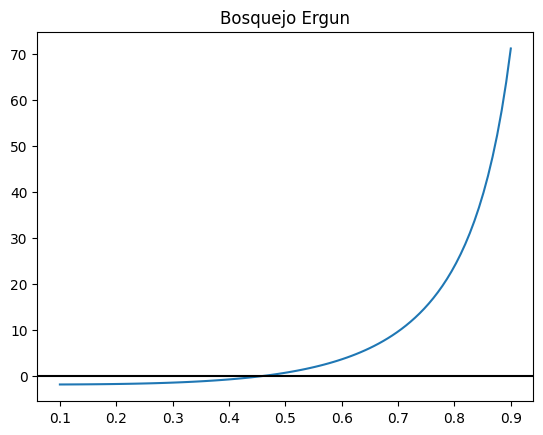

In [4]:
# Se necesita hallar la fraccion vacia epsilon para un lecho con parametros especificos

def  f_ergun(e):
    return (10 * e ** 3 / (1 - e)) - (150 * (1 - e) / 1000) - 1.75

# fraccionn vaica usando el metodo de biseccion
sol_bis = c.Biseccion(f_ergun, 0.3, 0.7, 1e-6)

# fraccion vacia usando el metodo de Secante
sol_sec, iter_sec = c.Secante(f_ergun, 0.4, 0.5, 1e-6)

print(f"Epsilon (Biseccion): {sol_bis}")
print(f"Epsilon (Secante): {sol_sec}")

# Bosquejo de la grafica
e_vals = np.linspace(0.1, 0.9, 100)
plt.plot(e_vals, f_ergun(e_vals))
plt.axhline(0, color='black')
plt.title("Bosquejo Ergun")
plt.show()

# Justificacion: El valor obtenido 0.46 es aceptable para la fraccion vacia 
# cumpliendo con la precision requerida por los metodos numericos aplicados

# Ejercicio 3


Un cable en forma catenaria es aquel que cuelga entre dos puntos que no se encuentran sobre la misma línea vertical. Como se ilustra en la figura (a), no está sujeta a más carga que su propio peso. Así, su peso (N/m) actúa como una carga uniforme por unidad de longitud a lo largo del cable. En la figura (b), se ilustra un diagrama de cuerpo libre de una sección AB, donde $T_A$ y $T_B$

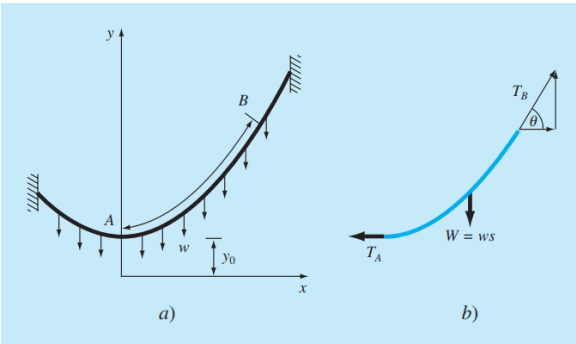


 son las fuerzas de tensión en el extremo. Con base en los balances de fuerzas horizontal y vertical, se obtiene para el cable el siguiente modelo de ecuación diferencial:$$\frac{d^2y}{dx^2} = \frac{\omega}{T_A} \sqrt{1 + \left( \frac{dy}{dx} \right)^2}$$Puede emplearse el cálculo para resolver esta ecuación para la altura $y$ del cable como función de la distancia $x$.$$y = \frac{T_A}{\omega} \cosh \left( \frac{\omega}{T_A} x \right) + y_o - \frac{T_A}{\omega}$$donde el coseno hiperbólico se calcula por medio de la ecuación:$$\cosh x = \frac{e^x + e^{-x}}{2}$$Realizar el bosquejo de la gráfica de la función de ceros.Utilice un método para calcular un valor para el parámetro $T_A$ dados los valores de los parámetros $\omega = 12$ y $y_o = 6$, de modo que el cable tenga una altura de $y = 15$ en $x = 50$.De una justificación de su respuesta.

La tension horizontal Ta calculada es: 1684.3650968173959
Iteraciones realizadas: 4


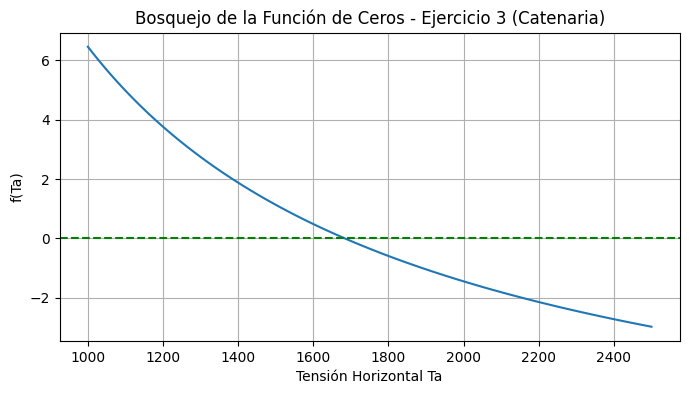

In [5]:
# Necesitamos determinar la tennsionn horizontal Ta para que un cable w = 12
# y0 = 6  alcance y = 15 x = 50

# parametros
w = 12
y0 = 6
x_val = 50
y = 15

Ta_sym = sp.symbols('x')

# Funcion
f_sim = (Ta_sym / w) * (sp.cosh((w / Ta_sym) * x_val)) + y0 - (Ta_sym / w) - y
f_num = sp.lambdify(Ta_sym, f_sim, 'numpy')

# Metodo newton
sol_ta, it_cat = c.Secante(f_num, 1600, 1700, 1e-4)
print(f"La tension horizontal Ta calculada es: {sol_ta}")
print(f"Iteraciones realizadas: {it_cat}")


# Bosquejo de la grafica
Ta_range = np.linspace(1000, 2500, 100)
plt.figure(figsize=(8, 4))
plt.plot(Ta_range, f_num(Ta_range))
plt.axhline(0, color='green', linestyle='--')
plt.title("Bosquejo de la Función de Ceros - Ejercicio 3 (Catenaria)")
plt.xlabel("Tensión Horizontal Ta")
plt.ylabel("f(Ta)")
plt.grid(True)
plt.show()

# justificacion: el valor de Ta = 1684.3 N es el unico que satisface la geometria
# del cable para que bajo un peso de 12 N/m y partirendo de una altura de 6m alcance
# los 15 m de altura a una distanncia horizontal de 50m

# Ejercicio 4

Descomponga en fracciones parciales las siguientes funciones racionales:$$F(s) = \frac{52.5s(s + 1)(s + 1.5)(s + 5)}{s^4 + 20.75s^3 + 92.6s^2 + 73.69s}$$es decir, determine las raíces utilizando un método de búsqueda de raíces, use los 4 métodos para determinar una raíz diferente.

Biseccion
La solucion de al funcion: -4.886839866638184
La cantidad de iteraciones necesarias fueron 20
Posicion Falsa
La solucion de al funcion: -8.375689808381992e-09
La cantidad de iteraciones necesarias fueron 21
Raiz Newton: -14.847553221027528
Raiz Biseccion: -4.886839866638184
Raiz Secante: -1.015606645465096
Raiz Posicion Falsa: -8.375689808381992e-09


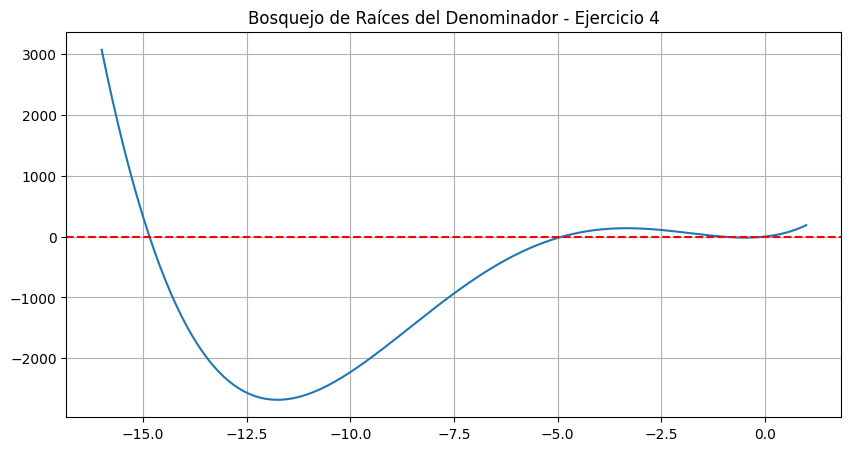

In [ ]:
x = sp.symbols('x')

f_sim = x ** 4 + 20.75 * x ** 3 + 92.6 * x ** 2 + 73.69 * x
f_num = sp.lambdify(x, f_sim, 'numpy')

# Newton
raiz_newton, it_n = c.Newton(f_sim, -14, 1e-6)

# Biseccion
raiz_biseccion = c.Biseccion(f_num, -5, -4, 1e-6)

#Secante
raiz_secante, it_s = c.Secante(f_num, -1.5, -0.5, 1e-6)

# Posicion Falsa
raiz_falsa = c.PosicionFalsa(f_num, -0.5, 0.5, 1e-6)

print(f"Raiz Newton: {raiz_newton}")
print(f"Raiz Biseccion: {raiz_biseccion}")
print(f"Raiz Secante: {raiz_secante}")
print(f"Raiz Posicion Falsa: {raiz_falsa}")


s_graf = np.linspace(-16, 1, 400)
plt.figure(figsize=(10, 5))
plt.plot(s_graf, f_num(s_graf))
plt.axhline(0, color='red', linestyle='--')
plt.title("Bosquejo de Raíces del Denominador - Ejercicio 4")
plt.grid(True)
plt.show()

# justificacion: Primero se descompuso en fracciones parciales la funcion, se determino las raices
# del polinomio del denominador D(s) raiz  s=0 por inspeccion ya uqe todos los terminos
# dependen de s. Al sustituir los valores en el polinomio orignal D(s), el resultado tiende a cero
# dentro de la tolerancia (10^-6)